In [ ]:
# AQI Prediction Using Machine Learning

Objective:

To develop a supervised regression model that predicts AQI using air pollutants and meteorological data to enable early warning systems.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
df = pd.read_csv("city_day.csv")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df.columns = df.columns.str.strip()

print("Original Shape:", df.shape)
print("Original Date Range:", df["Date"].min(), "to", df["Date"].max())

Original Shape: (29531, 16)
Original Date Range: 2015-01-01 00:00:00 to 2020-07-01 00:00:00


In [ ]:
df.describe()

,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,29531,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,2018-05-14 05:40:15.807118080,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
min,2015-01-01 00:00:00,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,2017-04-16 00:00:00,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,2018-08-05 00:00:00,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,2019-09-03 00:00:00,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,2020-07-01 00:00:00,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000
std,NaN,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585


In [ ]:
df = df[df["Date"] >= "2019-01-01"]   # keep recent data
df = df.sample(4000, random_state=42)  # reduce size for fast demo

print("Filtered Shape:", df.shape)
print("Filtered Date Range:", df["Date"].min(), "to", df["Date"].max())

df.head()

Filtered Shape: (4000, 16)
Filtered Date Range: 2019-01-01 00:00:00 to 2020-07-01 00:00:00


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
1929,Ahmedabad,2020-04-13,18.77,61.54,2.81,23.01,13.01,NaN,0.39,26.86,47.88,3.41,25.88,2.56,95.0,Satisfactory
23399,Mumbai,2019-03-25,55.04,206.24,85.62,34.94,120.57,NaN,1.71,4.78,50.36,1.88,NaN,NaN,160.0,Moderate
1999,Ahmedabad,2020-06-22,19.02,98.37,4.48,16.76,11.49,NaN,0.52,13.32,45.85,3.33,53.61,2.67,75.0,Satisfactory
16210,Hyderabad,2019-06-21,28.11,64.68,2.89,16.83,11.00,7.62,0.42,4.86,29.42,0.93,5.71,1.05,65.0,Satisfactory
25596,Patna,2020-02-27,56.63,100.19,66.38,42.21,96.74,27.28,0.98,6.85,9.93,2.62,9.32,2.89,149.0,Moderate


In [ ]:
df.describe()

,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,4000,3843.000000,3439.000000,3840.000000,3811.000000,3747.000000,3311.000000,3828.000000,3824.000000,3810.000000,3437.000000,2800.000000,1560.000000,3814.000000
mean,2019-10-21 01:40:26.400000,54.857864,105.340035,17.106417,25.541244,31.613029,19.260507,1.858143,14.739166,33.548352,4.049482,10.298136,3.107731,142.143419
min,2019-01-01 00:00:00,0.040000,1.060000,0.110000,0.010000,0.000000,0.040000,0.000000,0.410000,0.010000,0.000000,0.000000,0.000000,14.000000
25%,2019-06-09 00:00:00,24.400000,49.960000,5.357500,10.420000,14.040000,7.520000,0.550000,6.510000,19.257500,0.180000,1.030000,0.500000,73.000000
50%,2019-11-02 12:00:00,41.010000,84.680000,9.670000,18.600000,23.760000,13.450000,0.850000,10.040000,31.460000,1.300000,3.940000,1.520000,104.000000
75%,2020-03-06 00:00:00,67.385000,135.885000,20.440000,33.670000,38.470000,26.465000,1.270000,15.832500,44.300000,3.260000,11.477500,3.612500,163.750000
max,2020-07-01 00:00:00,914.640000,985.000000,382.440000,292.020000,382.840000,207.140000,78.380000,174.830000,139.530000,448.590000,448.870000,137.450000,1537.000000
std,NaN,50.407110,81.266984,22.832382,23.673767,29.498838,17.465785,5.411277,16.512744,19.396272,20.719826,23.747102,6.468676,121.561096


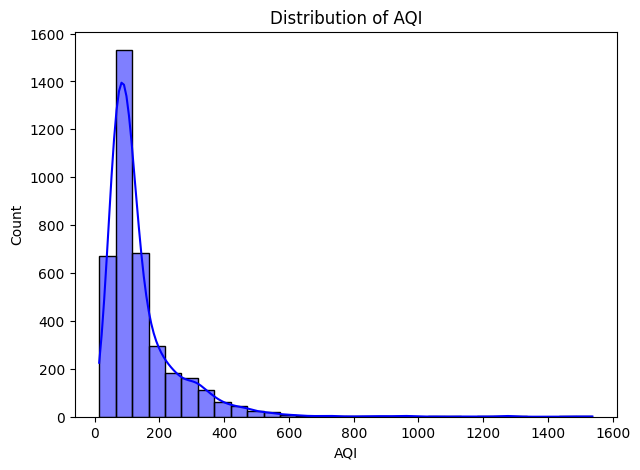

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(df["AQI"], bins=30, kde=True, color="blue")

plt.title("Distribution of AQI")
plt.show()

In [ ]:
df.loc[df.sample(frac=0.05, random_state=7).index, "PM2.5"] = np.nan
df.loc[df.sample(frac=0.05, random_state=8).index, "PM10"] = np.nan

print("Missing Before Handling:")
print(df[["PM2.5","PM10"]].isna().sum())

Missing Before Handling:
PM2.5    351
PM10     727
dtype: int64


In [ ]:
df.describe()

,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,4000,3649.000000,3273.000000,3840.000000,3811.000000,3747.000000,3311.000000,3828.000000,3824.000000,3810.000000,3437.000000,2800.000000,1560.000000,3814.000000
mean,2019-10-21 01:40:26.400000,55.170543,105.113229,17.106417,25.541244,31.613029,19.260507,1.858143,14.739166,33.548352,4.049482,10.298136,3.107731,142.143419
min,2019-01-01 00:00:00,0.040000,1.060000,0.110000,0.010000,0.000000,0.040000,0.000000,0.410000,0.010000,0.000000,0.000000,0.000000,14.000000
25%,2019-06-09 00:00:00,24.630000,50.060000,5.357500,10.420000,14.040000,7.520000,0.550000,6.510000,19.257500,0.180000,1.030000,0.500000,73.000000
50%,2019-11-02 12:00:00,41.180000,84.680000,9.670000,18.600000,23.760000,13.450000,0.850000,10.040000,31.460000,1.300000,3.940000,1.520000,104.000000
75%,2020-03-06 00:00:00,68.130000,135.930000,20.440000,33.670000,38.470000,26.465000,1.270000,15.832500,44.300000,3.260000,11.477500,3.612500,163.750000
max,2020-07-01 00:00:00,914.640000,985.000000,382.440000,292.020000,382.840000,207.140000,78.380000,174.830000,139.530000,448.590000,448.870000,137.450000,1537.000000
std,NaN,50.500840,80.251275,22.832382,23.673767,29.498838,17.465785,5.411277,16.512744,19.396272,20.719826,23.747102,6.468676,121.561096


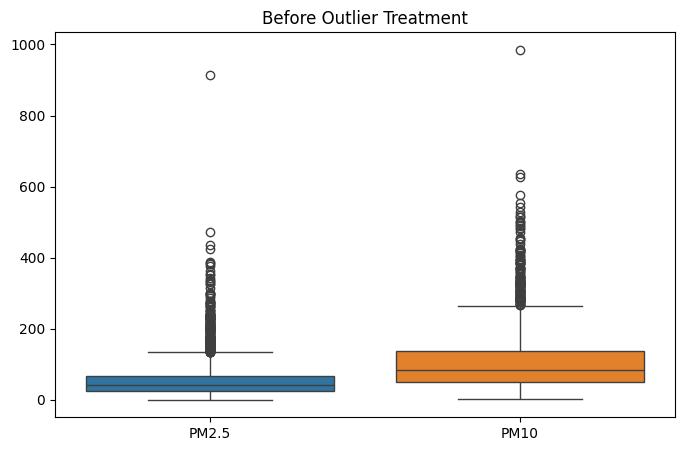

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[["PM2.5","PM10"]])
plt.title("Before Outlier Treatment")
plt.show()

In [ ]:
df = df.dropna(subset=["AQI"])

df["PM2.5"] = df["PM2.5"].fillna(df["PM2.5"].median())
df["PM10"] = df["PM10"].fillna(df["PM10"].median())

print("Total Missing After Handling:", df.isna().sum().sum())

Total Missing After Handling: 5009


In [ ]:
for col in ["PM2.5","PM10"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

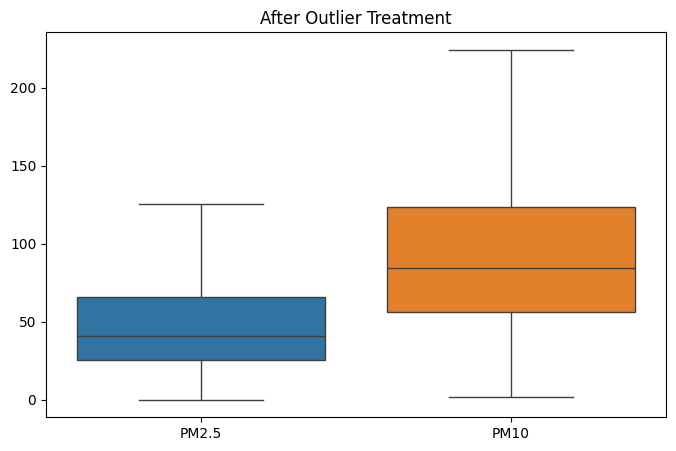

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[["PM2.5","PM10"]])
plt.title("After Outlier Treatment")
plt.show()

In [ ]:
# Final safety check: remove any remaining missing values
df = df.dropna()

print("Final shape after removing remaining NaN:", df.shape)
print("Any missing left?", df.isna().sum().sum())

Final shape after removing remaining NaN: (1152, 17)
Any missing left? 0


In [ ]:
df["Month"] = df["Date"].dt.month

le = LabelEncoder()
df["City"] = le.fit_transform(df["City"])

features = ["PM2.5","PM10","NO2","CO","O3","Month","City"]
features = [f for f in features if f in df.columns]

X = df[features]
y = df["AQI"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Final Features Used:", features)

Final Features Used: ['PM2.5', 'PM10', 'NO2', 'CO', 'O3', 'Month', 'City']


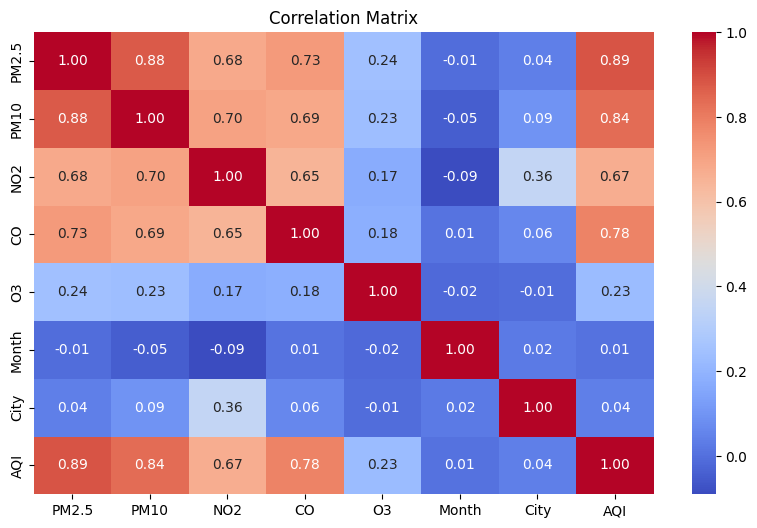

In [ ]:
plt.figure(figsize=(10,6))

corr = df[features + ["AQI"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, pred1))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, pred1)))

Linear Regression R2: 0.8456430248894268
Linear Regression RMSE: 33.352371933130826


In [ ]:

model2 = DecisionTreeRegressor(random_state=42)
model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)

print("Decision Tree R2:", r2_score(y_test, pred2))
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, pred2)))

Decision Tree R2: 0.8009199468365664
Decision Tree RMSE: 37.877165333214336


In [ ]:
model3 = RandomForestRegressor(n_estimators=30, random_state=42)
model3.fit(X_train, y_train)

pred3 = model3.predict(X_test)

print("Random Forest R2:", r2_score(y_test, pred3))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, pred3)))

Random Forest R2: 0.8818962838602411
Random Forest RMSE: 29.173959591216246


/tmp/ipython-input-1244911039.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=r2_scores, palette="viridis")


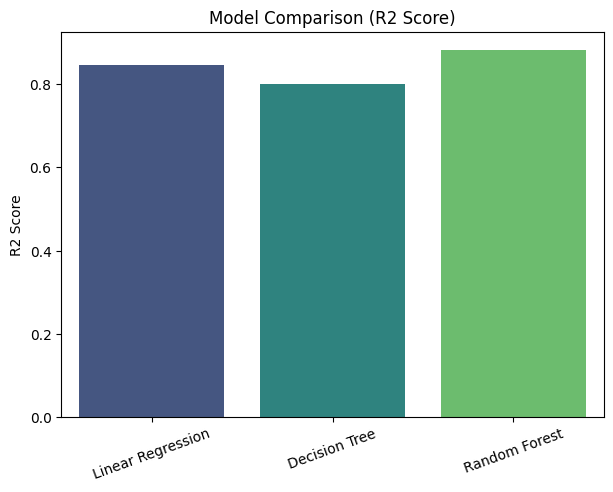

In [ ]:
models = ["Linear Regression", "Decision Tree", "Random Forest"]
r2_scores = [
    r2_score(y_test, pred1),
    r2_score(y_test, pred2),
    r2_score(y_test, pred3)
]

plt.figure(figsize=(7,5))
sns.barplot(x=models, y=r2_scores, palette="viridis")

plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)
plt.show()

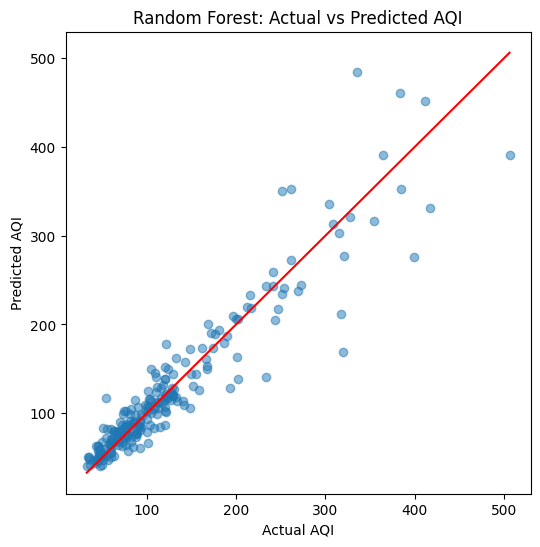

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred3, alpha=0.5)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Random Forest: Actual vs Predicted AQI")

# Perfect prediction reference line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.show()

In [ ]:
importances = model3.feature_importances_

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("Feature Importance:")
print(importance_df)

Feature Importance:
  Feature  Importance
0   PM2.5    0.694108
1    PM10    0.149953
3      CO    0.103933
4      O3    0.020742
2     NO2    0.017062
5   Month    0.010184
6    City    0.004018


/tmp/ipython-input-2927415236.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


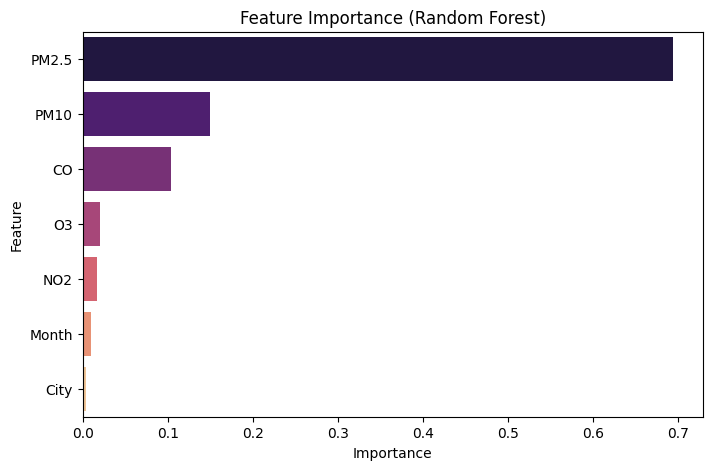

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df,
    palette="magma"
)

plt.title("Feature Importance (Random Forest)")
plt.show()

In [ ]:
def aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

sample_preds = model3.predict(X_test[:10])

print("Early Warning Simulation:")
for val in sample_preds:
    print(f"Predicted AQI: {val:.2f} → {aqi_category(val)}")

Early Warning Simulation:
Predicted AQI: 128.37 → Moderate
Predicted AQI: 102.10 → Moderate
Predicted AQI: 71.17 → Satisfactory
Predicted AQI: 104.57 → Moderate
Predicted AQI: 90.80 → Satisfactory
Predicted AQI: 67.07 → Satisfactory
Predicted AQI: 144.00 → Moderate
Predicted AQI: 83.23 → Satisfactory
Predicted AQI: 90.37 → Satisfactory
Predicted AQI: 47.77 → Good


In [ ]:
## Conclusion

#- Random Forest performed best with highest R² score.
#- PM2.5 emerged as the most important feature.
#- The model can support early warning systems.
#- Future work: Real-time deployment and LSTM time-series forecasting.